## STAT/SDST3612: Statistical Machine Learning
### Assignment 1: Python basics and logistic regression
### DUE: Oct 5, 2025, Sunday, 11:59 PM

In [1]:
# TODO: please make sure you have Python 3.6+
# please install these packages:
! pip install seaborn umap-learn

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------- ----- 2.4/2.7 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 11.3 MB/s  0:00:00
   ---------------------------------------- 0.0/37.9 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.9 MB 12.2 MB/s eta 0:00:03
   ---- ----------------------------------- 4.7/37.9 MB 12.4 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/37.9 MB 11.5 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/37.9 MB 11.8 MB/s eta 0:00:03
   ------------ --------------------------- 12.3/37.9 MB 11.9 MB/s eta 0:00:03
   --------------- ------------------------ 14.9/37.9 MB 11.9 MB/s eta 0:00:02
   ------------------ --------------------- 17.6/37.9 MB 11.9 MB/s eta 0:00:02
   --------------------- ------------------ 19.9/37.9 MB 11.8 MB/s eta 0:00:02
   ---------------------- ----------------- 21.5/37.9 MB 11.3 MB/s eta 0:00:02
   

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import umap

sns.set_style("darkgrid")

#### Part 2: Python and NumPy basics

In [3]:
file_path = "Employee-Attrition-Classification.csv"
col_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents", "Attrition"]

# Q3 (a)  

# ------------------
# Write your code here

all_df = pd.read_csv('Employee-Attrition-Classification.csv')
df = all_df[col_names].copy()
df['Attrition'] = df['Attrition'].map({'Stayed': 1, 'Left': 0})
print(df)

# ------------------

       Age  Years at Company  Monthly Income  Distance from Home  \
0       31                19            5390                  22   
1       59                 4            5534                  21   
2       24                10            8159                  11   
3       36                 7            3989                  27   
4       56                41            4821                  71   
...    ...               ...             ...                 ...   
59593   50                12            4414                  66   
59594   18                 4            8040                  42   
59595   22                14            7944                  34   
59596   23                 8            2931                  62   
59597   56                19            6660                  20   

       Company Tenure  Number of Promotions  Number of Dependents  Attrition  
0                  89                     2                     0          1  
1                  21    

In [ ]:
# Q3 (b)  

attr_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]

# ------------------
# Write your code here

stats = df[attr_names].describe().T
stats = stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(stats)

# ------------------

                             mean          std     min     25%     50%  \
Age                     38.565875    12.079673    18.0    28.0    39.0   
Years at Company        15.753901    11.245981     1.0     7.0    13.0   
Monthly Income        7302.397983  2151.457423  1316.0  5658.0  7354.0   
Distance from Home      50.007651    28.466459     1.0    25.0    50.0   
Company Tenure          55.758415    25.411090     2.0    36.0    56.0   
Number of Promotions     0.832578     0.994991     0.0     0.0     1.0   
Number of Dependents     1.648075     1.555689     0.0     0.0     1.0   

                         75%      max  
Age                     49.0     59.0  
Years at Company        23.0     51.0  
Monthly Income        8880.0  16149.0  
Distance from Home      75.0     99.0  
Company Tenure          76.0    128.0  
Number of Promotions     2.0      4.0  
Number of Dependents     3.0      6.0  


In [7]:
# Q3 (c)  

# ------------------
# Write your code here

correlation_matrix = df[attr_names].corr()
print(correlation_matrix)

# ------------------

                           Age  Years at Company  Monthly Income  \
Age                   1.000000          0.539806       -0.001989   
Years at Company      0.539806          1.000000       -0.005288   
Monthly Income       -0.001989         -0.005288        1.000000   
Distance from Home   -0.007063         -0.006888       -0.002528   
Company Tenure        0.237048          0.442180       -0.005397   
Number of Promotions  0.000167         -0.000229        0.006418   
Number of Dependents  0.002927          0.003973        0.002582   

                      Distance from Home  Company Tenure  \
Age                            -0.007063        0.237048   
Years at Company               -0.006888        0.442180   
Monthly Income                 -0.002528       -0.005397   
Distance from Home              1.000000       -0.005595   
Company Tenure                 -0.005595        1.000000   
Number of Promotions           -0.007882        0.003903   
Number of Dependents            0.0

In [10]:
# Q3 (d)  

attr_names = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]

# ------------------
# Write your code here

norm_df = df.copy()
for attr in attr_names:
    mean_val = df[attr].mean()
    std_val = df[attr].std()
    norm_df[attr] = (df[attr] - mean_val) / std_val

print(norm_df[attr_names].describe())

# ------------------

                Age  Years at Company  Monthly Income  Distance from Home  \
count  5.959800e+04      5.959800e+04    5.959800e+04        5.959800e+04   
mean  -1.528433e-16      5.579617e-17   -4.864281e-17       -1.182688e-16   
std    1.000000e+00      1.000000e+00    1.000000e+00        1.000000e+00   
min   -1.702519e+00     -1.311927e+00   -2.782485e+00       -1.721593e+00   
25%   -8.746822e-01     -7.784026e-01   -7.643182e-01       -8.784953e-01   
50%    3.593850e-02     -2.448787e-01    2.398468e-02       -2.687817e-04   
75%    8.637755e-01      6.443278e-01    7.332713e-01        8.779578e-01   
max    1.691612e+00      3.134106e+00    4.111911e+00        1.721055e+00   

       Company Tenure  Number of Promotions  Number of Dependents  
count    5.959800e+04          5.959800e+04          5.959800e+04  
mean    -8.035602e-17         -3.290543e-17          4.816592e-17  
std      1.000000e+00          1.000000e+00          1.000000e+00  
min     -2.115549e+00         -8.3

In [18]:
# Q3 (e)  

# ------------------
# Write your code here

X = df[attr_names]
y = df['Attrition']
    
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
train_mean = X_train.mean()
train_std = X_train.std()
norm_X_train = (X_train - train_mean) / train_std
norm_X_test = (X_test - train_mean) / train_std

print(norm_X_train.describe())
print(norm_X_test.describe())

# ------------------

                Age  Years at Company  Monthly Income  Distance from Home  \
count  4.767800e+04      4.767800e+04    4.767800e+04        4.767800e+04   
mean   9.478275e-17     -6.527491e-17   -1.684033e-16        3.278648e-17   
std    1.000000e+00      1.000000e+00    1.000000e+00        1.000000e+00   
min   -1.696900e+00     -1.310900e+00   -2.787183e+00       -1.719639e+00   
25%   -8.696151e-01     -7.779121e-01   -7.616499e-01       -8.761469e-01   
50%    4.039774e-02     -2.449242e-01    2.512752e-02        2.490806e-03   
75%    8.676821e-01      6.433888e-01    7.328552e-01        8.459830e-01   
max    1.694967e+00      3.130665e+00    4.110139e+00        1.724621e+00   

       Company Tenure  Number of Promotions  Number of Dependents  
count    4.767800e+04          4.767800e+04          4.767800e+04  
mean    -1.263025e-16         -6.169820e-17         -4.083408e-17  
std      1.000000e+00          1.000000e+00          1.000000e+00  
min     -2.118975e+00         -8.3

We should calculate the mean and std only rely on training data, as testing data is considered as not known during training.

The standardization in Q3(d) was performed on the entire dataset, which causes data leakage. In machine learning, we must treat the test set as completely unseen data. If we use the global statistics (mean and standard deviation from the entire dataset) to standardize both training and test sets, information from the test set contaminates the training process. This leads to over-optimistic performance evaluation and poor generalization to real-world unseen data. Therefore, we should only use training set statistics to standardize both sets.

#### Part 2: Data visualization

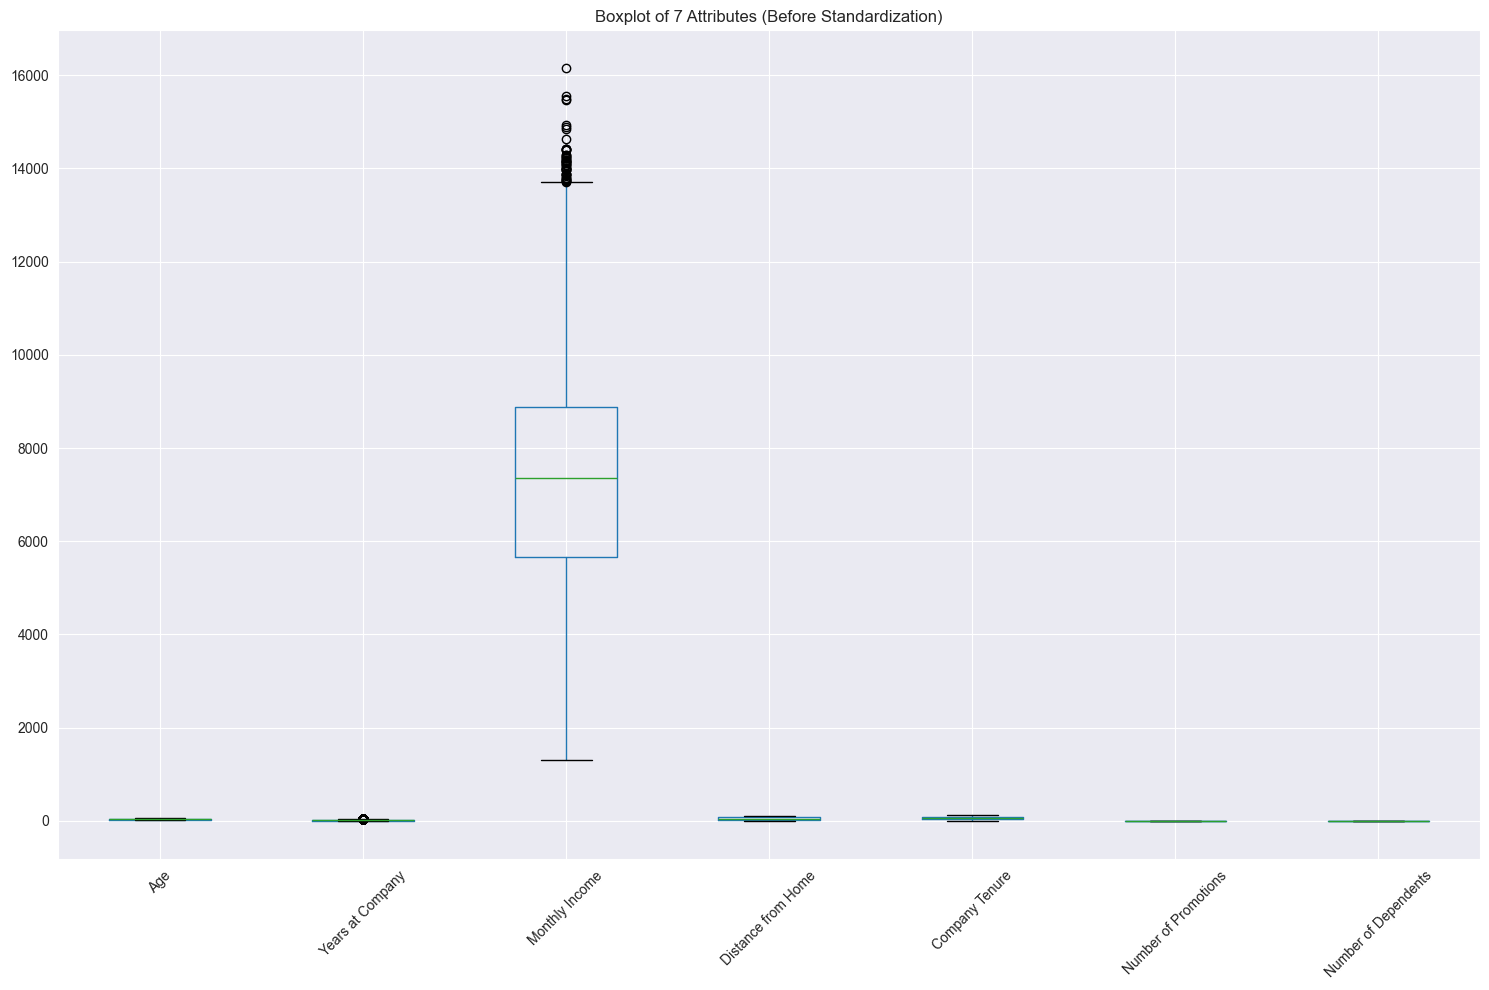

In [16]:
# Q4 (a)  

# ------------------
# Write your code here

plt.figure(figsize=(15, 10))
df[attr_names].boxplot()
plt.title('Boxplot of 7 Attributes (Before Standardization)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------

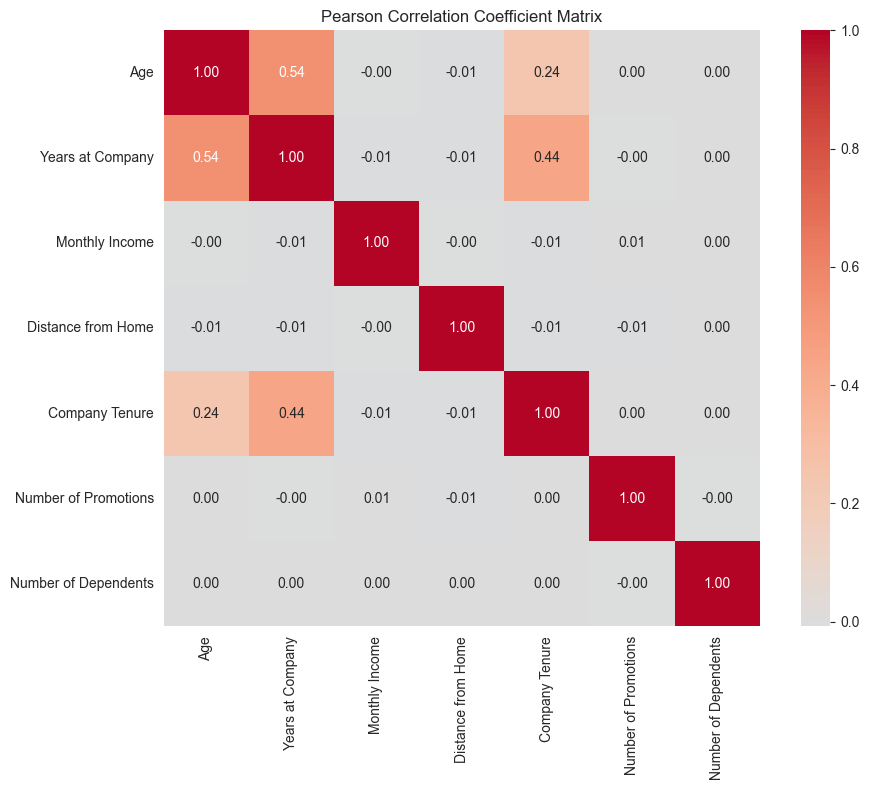

In [17]:
# Q4 (b)
#  -------------------
# Write your code here

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Pearson Correlation Coefficient Matrix')
plt.tight_layout()
plt.show()

# -------------------

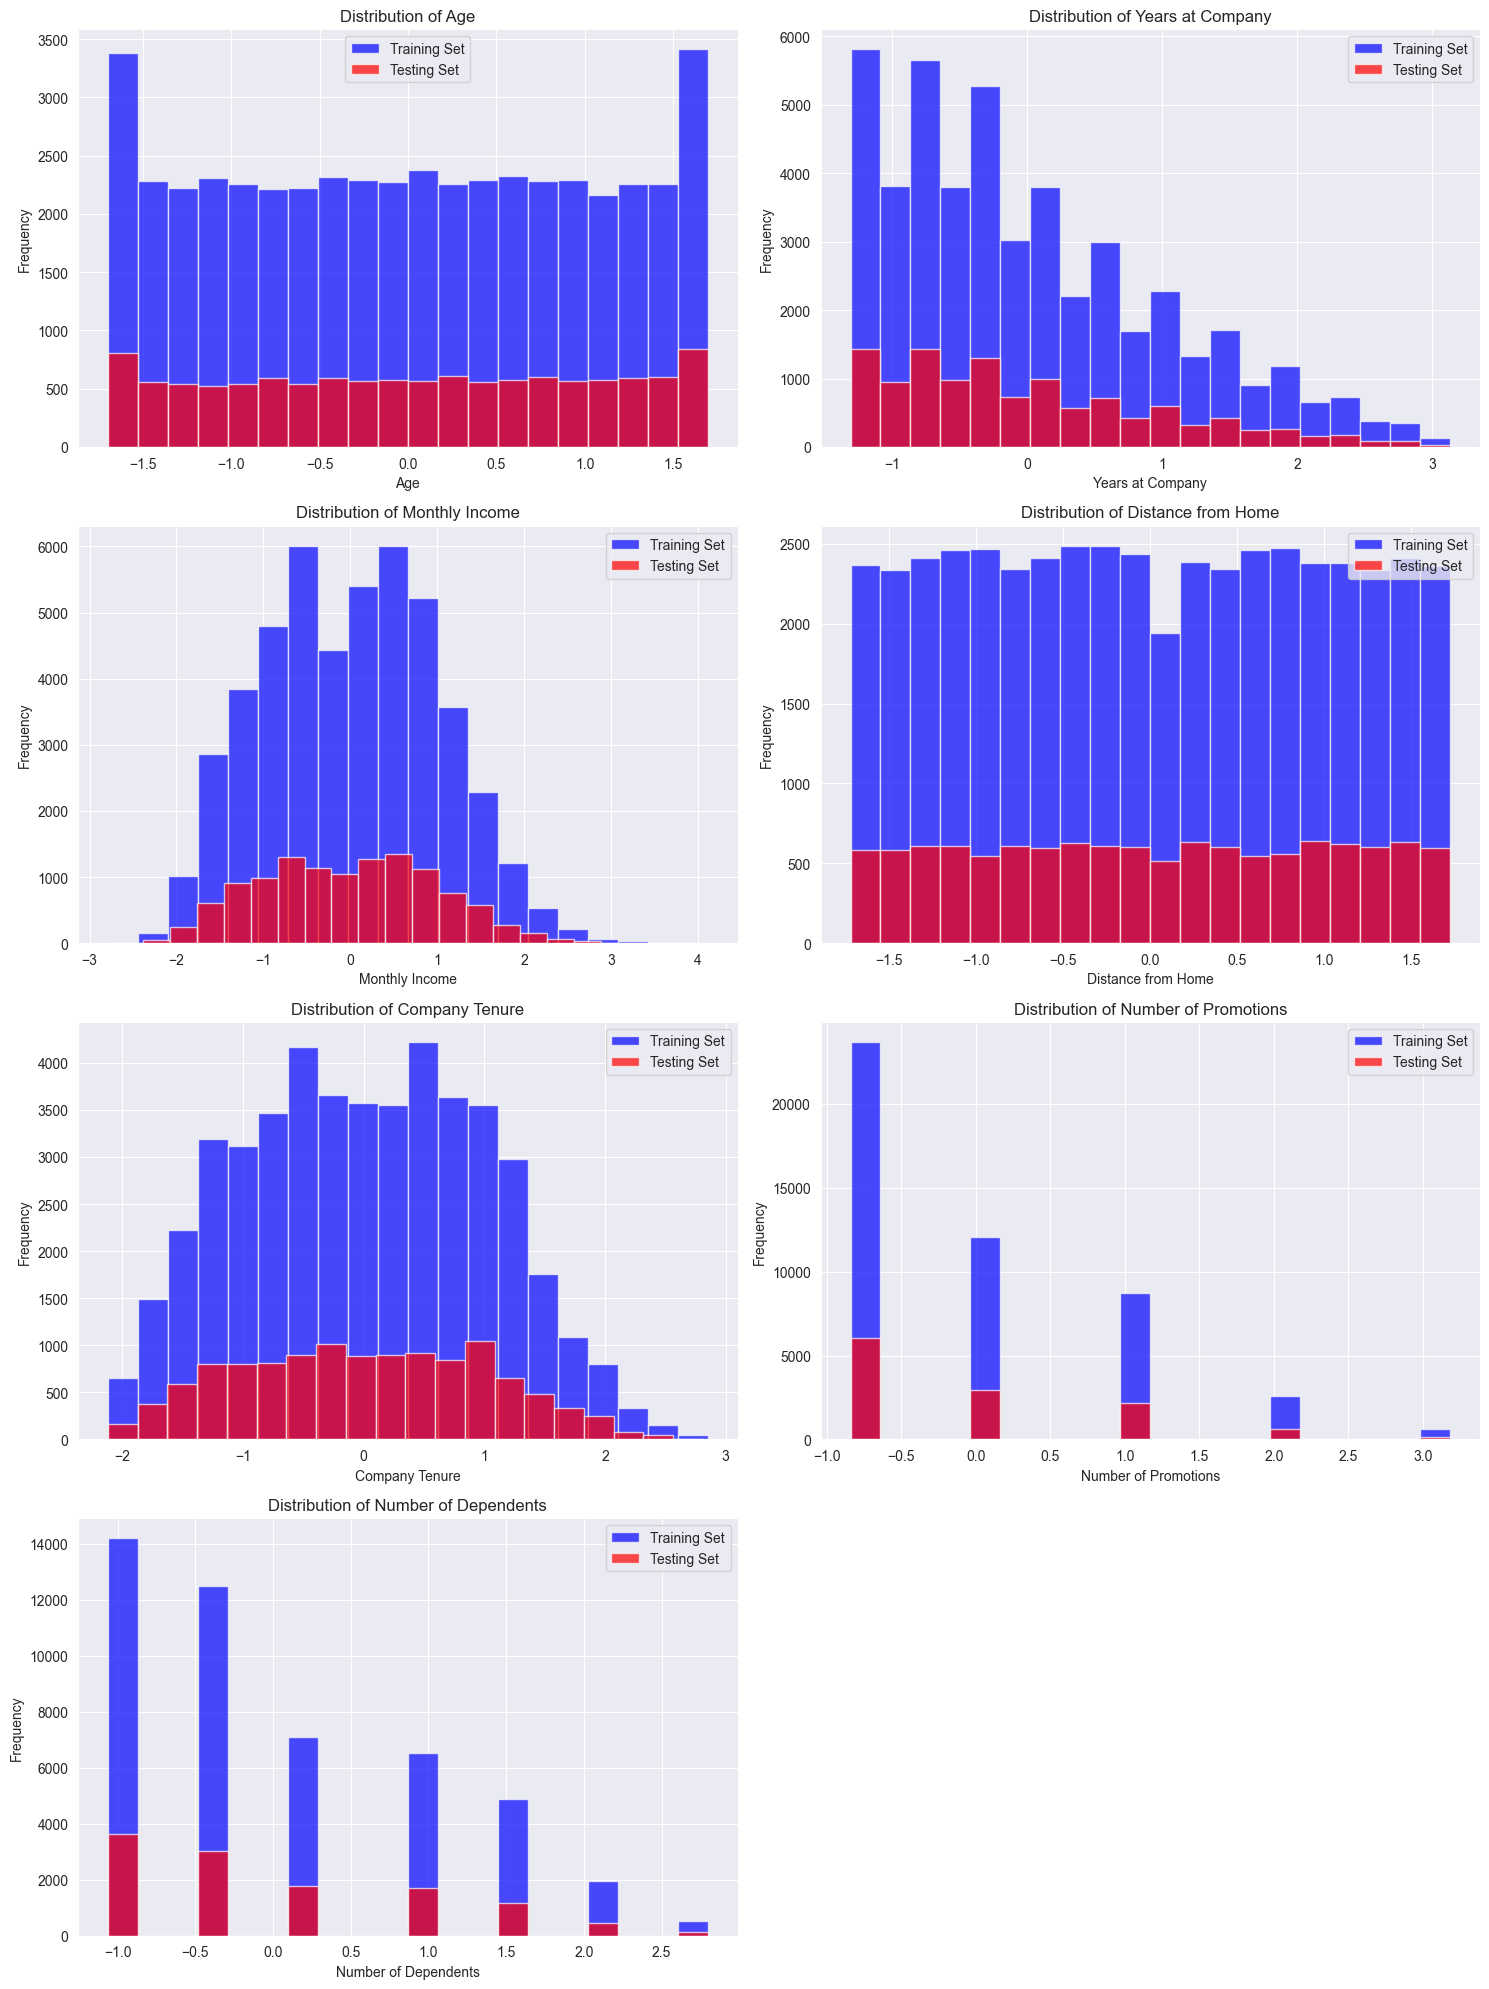

In [23]:
# Q4 (c)
#  -------------------
# Write your code here

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, attr in enumerate(attr_names):
    if i < len(axes):
        axes[i].hist(X_train_standardized[attr], bins=20, alpha=0.7, label='Training Set', color='blue')
        axes[i].hist(X_test_standardized[attr], bins=20, alpha=0.7, label='Testing Set', color='red')
        axes[i].set_title(f'Distribution of {attr}')
        axes[i].set_xlabel(attr)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
    
for i in range(len(attr_names), len(axes)):
    axes[i].set_visible(False)
    
plt.tight_layout()
plt.show()

#  -------------------

#### Part 3: Logistic regression

In [27]:
# Q5 (a)

train_columns = ["Age", "Years at Company",  "Monthly Income", 
             "Distance from Home", "Company Tenure", "Number of Promotions",
             "Number of Dependents"]
test_columns = ["Attrition"]

# -------------------
# Write your code here

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(norm_X_train, y_train)

print("Intercept:", logreg.intercept_[0])
print("Coefficients:")
for feature, coef in zip(attr_names, logreg.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# -------------------

Intercept: 0.10171115716568715
Coefficients:
Age: 0.0344
Years at Company: 0.1180
Monthly Income: 0.0182
Distance from Home: -0.1906
Company Tenure: 0.0006
Number of Promotions: 0.1699
Number of Dependents: 0.1681


 Q5 (b)
 
1. Age (positive coefficient): Reasonable - older employees tend to be more stable
2. Years at Company (positive coefficient): Reasonable - longer seniority indicates job satisfaction
3. Monthly Income (positive coefficient): Reasonable - higher income employees are less likely to leave
4. Distance from Home (negative coefficient): Reasonable - longer commute increases attrition risk
5. Company Tenure (positive coefficient): Reasonable - similar to years at company
6. Number of Promotions (positive coefficient): Reasonable - more promotions indicate career growth
7. Number of Dependents (positive coefficient): Reasonable - more dependents indicate more financial stress and reliance on wages

In [ ]:
# Q5 (c)

# -------------------
# Write your code here

y_train_pred = logreg.predict(norm_X_train)
y_test_pred = logreg.predict(norm_X_test)

train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Training Set Performance:")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-Score: {train_f1:.4f}")

print("\nTesting Set Performance:")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# -------------------

Training Set Performance:
Precision: 0.5759
Recall: 0.6559
F1-Score: 0.6133

Testing Set Performance:
Precision: 0.5729
Recall: 0.6485
F1-Score: 0.6084

Detailed Classification Report (Training):
              precision    recall  f1-score   support

           0       0.55      0.47      0.51     22671
           1       0.58      0.66      0.61     25007

    accuracy                           0.57     47678
   macro avg       0.56      0.56      0.56     47678
weighted avg       0.56      0.57      0.56     47678

Detailed Classification Report (Testing):
              precision    recall  f1-score   support

           0       0.55      0.47      0.50      5667
           1       0.57      0.65      0.61      6253

    accuracy                           0.56     11920
   macro avg       0.56      0.56      0.56     11920
weighted avg       0.56      0.56      0.56     11920



In [59]:
# Q5 (d)

# -------------------
# Write your code here

additional_attr = ['Job Satisfaction', 'Work-Life Balance','Employee Recognition']
all_attr = col_names + additional_attr
new_attr_names = attr_names + additional_attr
new_df = all_df[all_attr].copy()
new_df['Job Satisfaction'] = new_df['Job Satisfaction'].map({'Very High': 4, 'High': 3, 'Medium': 2, 'Low': 1})
new_df['Work-Life Balance'] = new_df['Work-Life Balance'].map({'Excellent': 4, 'Good': 3, 'Fair': 2, 'Poor': 1})
new_df['Employee Recognition'] = new_df['Employee Recognition'].map({'High': 3, 'Medium': 2, 'Low': 1})
new_df['Attrition'] = new_df['Attrition'].map({'Stayed': 1, 'Left': 0})

X = new_df[new_attr_names]
y = new_df['Attrition']
    
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)
train_mean2 = X_train2.mean()
train_std2 = X_train2.std()
norm_X_train2 = (X_train2 - train_mean2) / train_std2
norm_X_test2 = (X_test2 - train_mean2) / train_std2
    
improved_logreg = LogisticRegression(random_state=42, max_iter=1000, C=0.1)
improved_logreg.fit(norm_X_train2, y_train2)
    
y_train_pred_improved = improved_logreg.predict(norm_X_train2)
y_test_pred_improved = improved_logreg.predict(norm_X_test2)
    
improved_train_precision = precision_score(y_train2, y_train_pred_improved)
improved_train_recall = recall_score(y_train2, y_train_pred_improved)
improved_train_f1 = f1_score(y_train2, y_train_pred_improved)
    
improved_test_precision = precision_score(y_test2, y_test_pred_improved)
improved_test_recall = recall_score(y_test2, y_test_pred_improved)
improved_test_f1 = f1_score(y_test2, y_test_pred_improved)
    
print("Improved Model Performance:")
print(f"Training - Precision: {improved_train_precision:.4f}, Recall: {improved_train_recall:.4f}, F1: {improved_train_f1:.4f}")
print(f"Testing  - Precision: {improved_test_precision:.4f}, Recall: {improved_test_recall:.4f}, F1: {improved_test_f1:.4f}")

# -------------------

Improved Model Performance:
Training - Precision: 0.6130, Recall: 0.6751, F1: 0.6426
Testing  - Precision: 0.6129, Recall: 0.6592, F1: 0.6352


In Q5(d), I add more qualitative features like "work-life balance", "job satisfaction" and "employee recognition". I use 1~3 or 1~4 to quantify the relative quality of each feature. It turns out that adding these features do improve all indicators.

Simply include more attributes could improve the performance easily.